In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec


# Diabetes Analysis

Diabetes remains one of the most prevalent chronic illnesses worldwide, and early identification of diabetic symptoms plays an important role in preventing long-term complications. Patients often exhibit physiological signs—such as excessive thirst, frequent urination, fatigue, or sudden weight changes—before the disease progresses to more severe stages. Detecting early-stage diabetes using such observable symptoms may provide an accessible way to screen individuals at risk, particularly in settings where formal laboratory testing is less available.

This study investigates whether physiological features are sufficient to classify an individual as early-stage diabetic using machine learning methods. By analyzing symptom-based patient data, we aim to determine how well modern predictive models can distinguish early diabetic cases from non-diabetic cases.

# 1. Dataset

## 1.1 Dataset Description

In [2]:
df_raw = pd.read_csv("../files/early_diabetes_data.csv")
df_raw

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


The dataset used in this study consists of **520 patient records**, each observed on a set of physiological factors that is maybe associated with diabetes. The outcome variable, class, indicates whether a patient is categorized as Positive (early diabetic) or Negative (non-diabetic).

The dataset contains one continuous variable (Age) and 15 categorical predictor variables, each describing the presence or absence of a clinical condition or symptom. These variables include polyuria, polydipsia, sudden weight loss, weakness, polyphagia, partial paresis, and others that are known early clinical indicators of diabetes. Categorical variables are encoded using binary values (“Yes”/“No” or “Male”/“Female”).

The dataset was also collected from Syllhet Diabetes Hospital, Syllhet, Bangladesh

## 1.2 Data Wrangling

Since there were no missing values in the dataset, there was no data cleaning conducted. However, since the categorical variables were in string format, the values were encoded into 0s and 1s. Specifically, 1 for 'Female', 'Positive', or 'Yes'; and 0 for 'Male', 'Negative', or 'No'.

In [3]:
df_factored = df_raw.copy()

# flags for boolean indexing of columns
yn_flag = (df_raw.columns != "Age") & (df_raw.columns != "class") & (df_raw.columns != "Gender")
pred_flag = df_raw.columns != "class"

# Encoding Gender and class variables
df_factored["Gender"] = df_raw["Gender"].map(lambda x: 1 if x == "Female" else 0)
df_factored["class"] = df_raw["class"].map(lambda x: 1 if x == "Positive" else 0)

# encoding categorical variables(yes/no variables) in 0s and 1s
for col in df_raw.columns[yn_flag]:
    df_factored[col] = df_raw[col].map(lambda x: 1 if x == "Yes" else 0)

df_factored.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,0,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,0,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


# 2. Analysis

In [4]:
df = df_factored.copy()

target = df['class']
features = df.drop('class', axis = 1).copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 42)

## 2.1 Which symptoms are most strongly associated with diabetes, and why might these relationships exist?

To measure the association of the symptoms with diabetes, we shall use the difference in conditional probabilities. The difference in conditional probabilities measures how much more frequently a physiological factor occurs in diabetic patients compared to non-diabetic patients. **Larger positive differences indicate stronger associations with diabetes**, suggesting that these factors are more discriminative for identifying the disease.

In [4]:
df = df_factored.copy()

target = df['class']
features = df.drop('class', axis = 1).copy()

df["age_group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-40", "40-50", "50-60", "60+"]
)

cat_features = df.drop(columns=['Age', 'age_group']).copy()
age = df['Age'].copy()

cat_features = np.transpose(cat_features.groupby('class').mean())
cat_features.columns = ['Negative', 'Positive']
cat_features['Difference'] = cat_features['Positive'] - cat_features['Negative']

cat_features.sort_values(by='Difference', ascending=False, inplace=True)
cat_features['Factors'] = cat_features.index
cat_features.reset_index(drop=True, inplace=True)

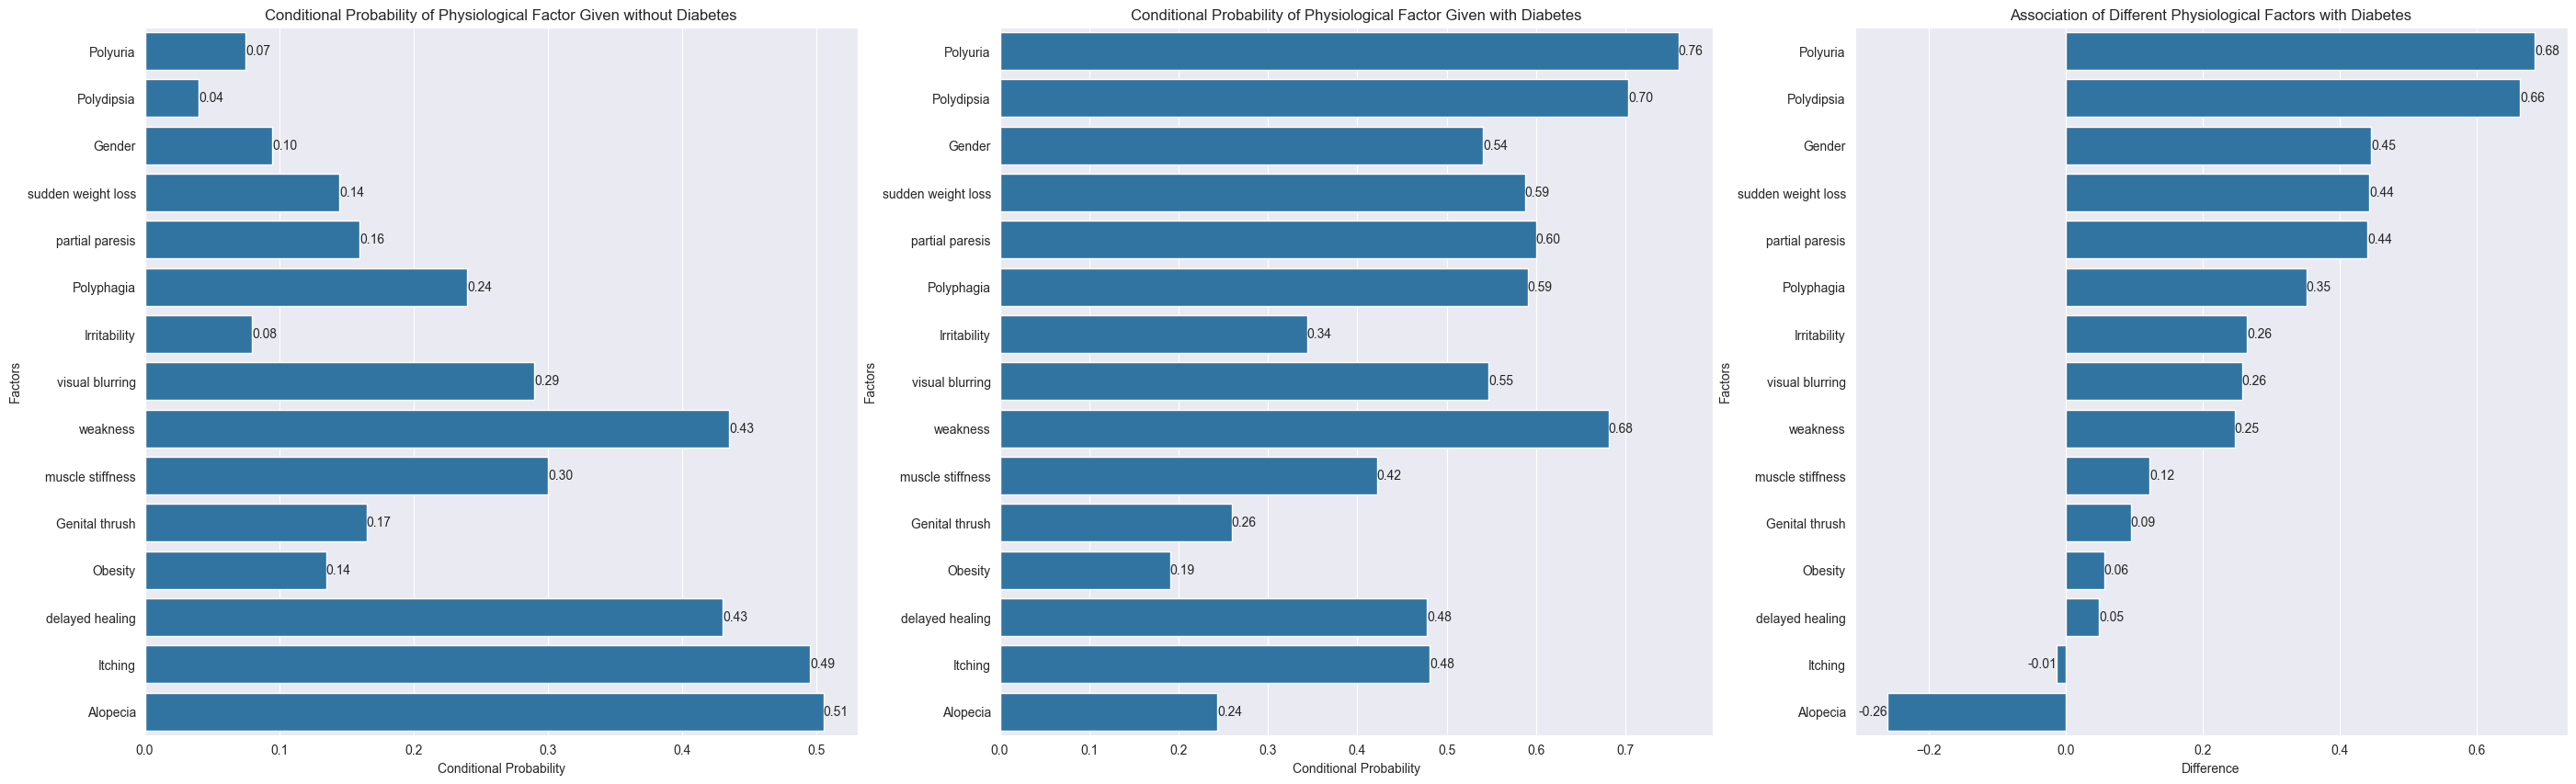

In [6]:
fig, axs = plt.subplots(1,3, figsize=(34, 10))
labels = ['Negative', 'Positive', 'Difference']

for idx, ax in enumerate(axs.flatten()):
    x = labels[idx]
    sns.barplot(data=cat_features, x=x, y ='Factors', ax=ax)

    if x == 'Negative':
        ax.set_xlabel(f'Conditional Probability')
        ax.set_title('Conditional Probability of Physiological Factor Given without Diabetes')
    elif x == 'Positive':
        ax.set_xlabel(f'Conditional Probability')
        ax.set_title('Conditional Probability of Physiological Factor Given with Diabetes')
    else:
        ax.set_xlabel(f'Difference')
        ax.set_title('Association of Different Physiological Factors with Diabetes')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

plt.savefig("q1.pdf", bbox_inches="tight")
plt.savefig("q1.png", bbox_inches="tight")

From the graph above, it shows that both Polyuria and Polydipsia have the highest association with Diabetes with a difference in conditional probabilities of 0.68 and 0.66, respectively. Polydipsia and Polyuria arise due to osmotic diuresis, where excess glucose in the blood—caused by diabetes—leads to increased urine production and subsequent dehydration (American Diabetes Association, 2023). Similarly, polyphagia and weight loss occur because the body cannot effectively utilize glucose, leading to increased hunger and breakdown of fat and muscle for energy (Mayo Clinic, 2023).

- Polyuria and Polydipsia have an association of 0.66 and 0.66, respectively.
-

## 2.2 Can a small subset of symptoms explains most diabetes cases, and what does this suggest about early detection?

In [7]:
df = df_factored.copy()

target = df['class']
features = df.drop('class', axis = 1).copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 42)


In [8]:
log_reg_results = {
    'Number of Coefficients' : [],
    'Value' : [],
    'Metric' : []
}

roc_auc_cum_df = []

log_reg = LogisticRegression(l1_ratio=1, solver='liblinear', random_state=42)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

gcv = GridSearchCV(log_reg, param_grid=param_grid, cv=5, n_jobs=-1)
gcv.fit(X_train, y_train)
opt_log_reg = gcv.best_estimator_
coef = opt_log_reg.coef_

coef_dict = {
    'coef': np.exp(coef.ravel()),
    'features': features.columns,
}

# Predictions
y_pred = opt_log_reg.predict(X_test)

y_pred_proba = opt_log_reg.predict_proba(X_test)[:, 1]
y_pred = opt_log_reg.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

log_reg_results['Number of Coefficients'].append(len(X_train.columns))
log_reg_results['Number of Coefficients'].append(len(X_train.columns))

roc_auc = roc_auc_score(y_test, y_pred_proba)
log_reg_results['Value'].append(roc_auc)
log_reg_results['Metric'].append('ROC AUC Score')

accuracy = accuracy_score(y_test, y_pred)
log_reg_results['Value'].append(accuracy)
log_reg_results['Metric'].append('Accuracy')

roc_curve_df = pd.DataFrame(
    data= {
        'fpr': fpr,
        'tpr': tpr,
    },
    columns=['fpr', 'tpr']
)

roc_auc_cum_df.append(roc_curve_df)

coef_df = (pd.DataFrame(coef_dict)
           .sort_values(by=['coef'], ascending=False))


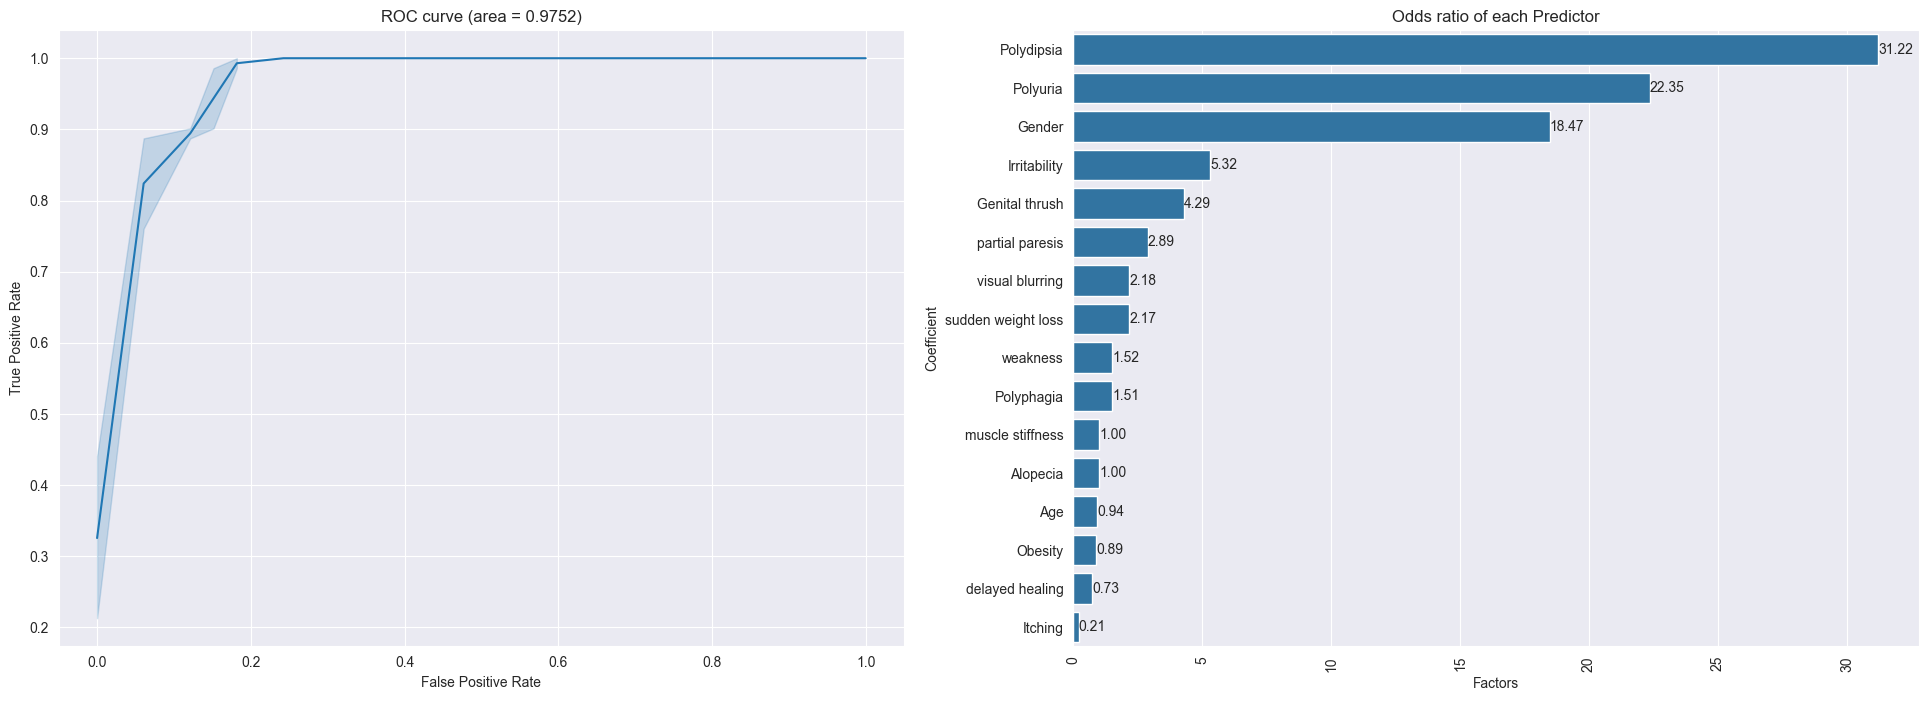

In [9]:
fig, axs = plt.subplots(1,2, figsize=(24, 8))

for idx, ax in enumerate(axs.flatten()):
    if idx == 0:
        sns.lineplot(data=roc_curve_df, x='fpr', y='tpr', ax=ax)
        ax.set_title(f"ROC curve (area = {round(roc_auc, 4)})")
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
    else:
        sns.barplot(data=coef_df, y = 'features', x = 'coef',ax = ax)
        ax.tick_params(axis='x', rotation=90)
        ax.set_ylabel('Coefficient')
        ax.set_xlabel('Factors')
        ax.set_title('Odds ratio of each Predictor')

        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f')

We can see from the graph on the right that Polydipsia, Polyuria, and Gender have extremely high odds ratio relative to other symptoms with the odds ratio being 31.22, 22.35, and 18.47, respectively. This implies that having Polydipsia increases the odds of having diabetes by a factor of 31.22, and this is the same for the other symptoms as well. This places the three symptoms as the three symptoms. Furthermore, we can see that Irritability and Genital Thrush places in top four and top five with odds ratio of 5.32 and 4.29, respectively. The ratio is smaller than the top three, however, it's a little bit bigger than the rest.

Now, we explore whether selecting the top 3 and top 5 subsets suggest that a smaller portion of symptoms is enough to predict diabetes. We shall do this by training two models with one using the top 3 features as predictors while the other uses the top 5. We then compare their performance.

In [10]:
num_of_coef = [5,3]
coef_top = coef_df.nlargest(5, 'coef')

for n in num_of_coef:
    coef_top = coef_df.nlargest(n, 'coef')
    coef_col = np.unique(coef_top['features'])

    log_reg_results['Number of Coefficients'].append(n)
    log_reg_results['Number of Coefficients'].append(n)

    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    }

    gcv = GridSearchCV(log_reg, param_grid=param_grid, cv=5, n_jobs=-1)
    gcv.fit(X_train.loc[:,coef_col], y_train)
    opt_log_reg = gcv.best_estimator_

    y_pred = opt_log_reg.predict(X_test.loc[:,coef_col])

    y_pred_proba = opt_log_reg.predict_proba(X_test.loc[:,coef_col])[:, 1]
    y_pred = opt_log_reg.predict(X_test.loc[:,coef_col])

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    log_reg_results['Value'].append(roc_auc)
    log_reg_results['Metric'].append('ROC AUC Score')

    accuracy = accuracy_score(y_test, y_pred)
    log_reg_results['Value'].append(accuracy)
    log_reg_results['Metric'].append('Accuracy')

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

    roc_curve_df = pd.DataFrame(
        data={
            'fpr': fpr,
            'tpr': tpr,
            },
        columns=['fpr', 'tpr']
    )

    roc_auc_cum_df.append(roc_curve_df)

log_reg_results = pd.DataFrame(log_reg_results)

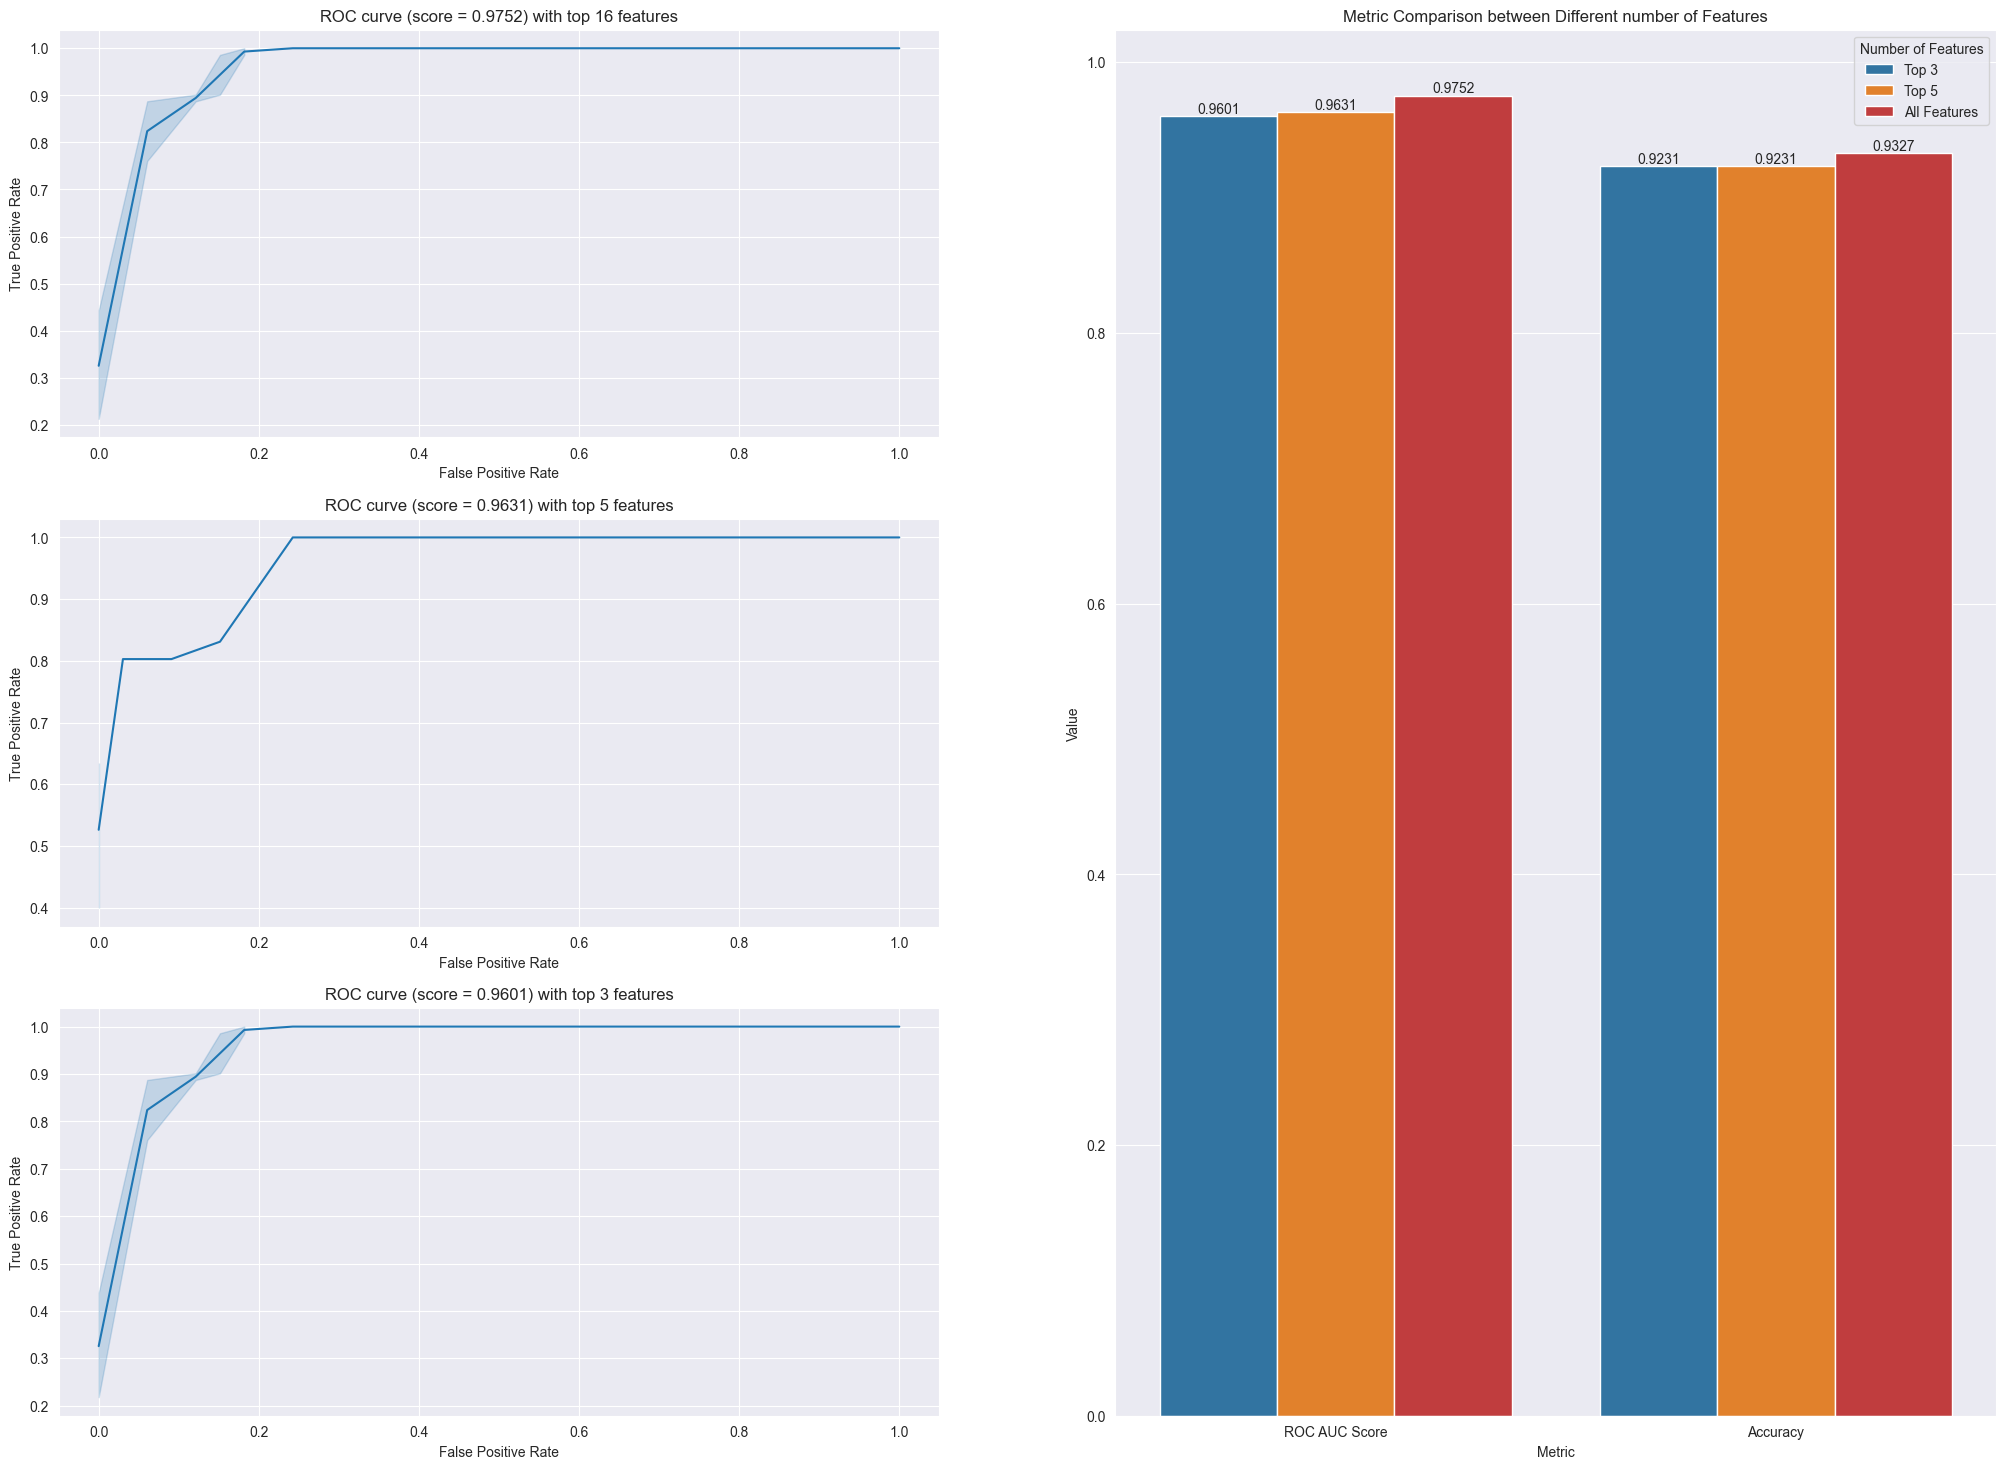

In [11]:
fig = plt.figure(figsize = (25, 18))
gs = gridspec.GridSpec(3, 2, height_ratios=[2, 2, 2])

ax = fig.add_subplot(gs[0, 0])
ax = sns.lineplot(data=roc_auc_cum_df[0], x='fpr', y='tpr')

n = 16
n_coef_df = pd.DataFrame(
    data = log_reg_results[log_reg_results['Number of Coefficients'] == n],
)

roc_score = n_coef_df.loc[n_coef_df['Metric'] == 'ROC AUC Score', 'Value'].copy().reset_index(drop=True)[0]
accuracy = n_coef_df.loc[n_coef_df['Metric'] == 'Accuracy', 'Value'].copy().reset_index(drop=True)[0]
coef_size = n

ax.set_title(f"ROC curve (score = {round(roc_score, 4)}) with top {n} features")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')


n = 5
n_coef_df = pd.DataFrame(
    data = log_reg_results[log_reg_results['Number of Coefficients'] == n],
)

ax0 = fig.add_subplot(gs[1, 0])
ax0 = sns.lineplot(data=roc_auc_cum_df[1], x='fpr', y='tpr')

roc_score = n_coef_df.loc[n_coef_df['Metric'] == 'ROC AUC Score', 'Value'].reset_index(drop=True)[0]
accuracy = n_coef_df.loc[n_coef_df['Metric'] == 'Accuracy', 'Value'].copy().reset_index(drop=True)[0]
coef_size = n

ax0.set_title(f"ROC curve (score = {round(roc_score, 4)}) with top {n} features")
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')

ax1 = fig.add_subplot(gs[2,0])
ax1 = sns.lineplot(data=roc_auc_cum_df[0], x='fpr', y='tpr')

n = 3
n_coef_df = pd.DataFrame(
    data = log_reg_results[log_reg_results['Number of Coefficients'] == n],
)

roc_score = n_coef_df.loc[n_coef_df['Metric'] == 'ROC AUC Score', 'Value'].copy().reset_index(drop=True)[0]
accuracy = n_coef_df.loc[n_coef_df['Metric'] == 'Accuracy', 'Value'].copy().reset_index(drop=True)[0]
coef_size = n

ax1.set_title(f"ROC curve (score = {round(roc_score, 4)}) with top {n} features")
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')


palette_map = {
    3: "#1f77b4",
    5: "#ff7f0e",
    16: "#d62728"
}

ax2 = fig.add_subplot(gs[:,1])
ax2 = sns.barplot(data=log_reg_results.sort_values(by='Value', ascending=False), x='Metric', y='Value', hue='Number of Coefficients', palette=palette_map)

handles, labels = ax2.get_legend_handles_labels()

new_labels = ["Top 3", "Top 5", "All Features"]

ax2.legend(handles, new_labels, title="Number of Features")
ax2.set_title('Metric Comparison between Different number of Features')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f')

plt.savefig("q2.pdf", bbox_inches="tight")


According to the graph on the right, we see a drop in all metrics as we select a smaller subset of symptoms. However, we can observe that the decrease from 16 symptoms to three symptoms is less than 0.01. Despite limiting the number of symptoms to use as predictors, the predictive performance of the model—that only uses the top three features as predictors—only decreased by a trivial amount. This is a strong signal that most of the symptoms are redundant and irrelevant.

The results show that a small subset of symptoms—particularly polydipsia, polyuria, and gender—captures most of the predictive signal, as reduced models perform comparably to the full model.

## 2.3 How does age influence the presence of diabetes?

In [5]:
df = df_factored.copy()

target = df['class']
features = df.drop('class', axis = 1).copy()

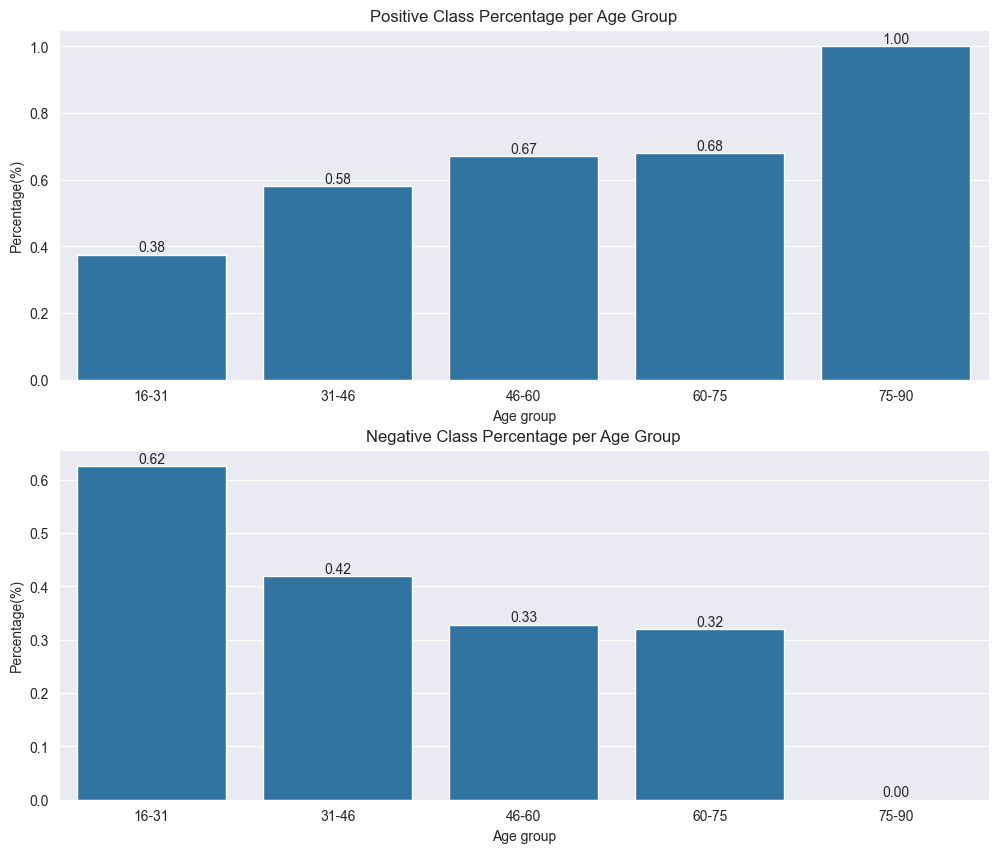

In [6]:
min_val = np.min(df['Age'].astype(int))
max_val = np.max(df['Age'].astype(int))

n_bins = 5
bins = np.linspace(min_val, max_val, n_bins + 1)
bins = np.round(bins).astype(int)

bins = np.unique(bins)
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
df["Age group"] = pd.cut(df['Age'], bins=bins, labels=bin_labels, include_lowest=True)

labels = ['Age group', 'class']
sliced = df.loc[:,labels]

new_labels = ['Age group', 'Positive', 'Negative']

diabetes_per_df = sliced.groupby('Age group').mean().reset_index()
diabetes_per_df['Negative'] = 1 - diabetes_per_df['class']
diabetes_per_df.columns = new_labels

fig, axs = plt.subplots(2,1,figsize=(12,10))

for idx, ax in enumerate(axs.flat):
    occur = ['Positive', 'Negative']

    sns.barplot(data=diabetes_per_df, x = 'Age group', y = occur[idx], ax=ax)
    ax.set_ylabel('Percentage(%)')
    ax.set_title(f'{occur[idx]} Class Percentage per Age Group')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

From the graph above, we can see that as age increases, the percentage of diabetes diagnosis increases as well. This implies that age has a positive relationship with having diabetes.

Taking the results from 2.2, we shall examine the relationship of diabetes with the occurence of the top three symptoms per Age Group.

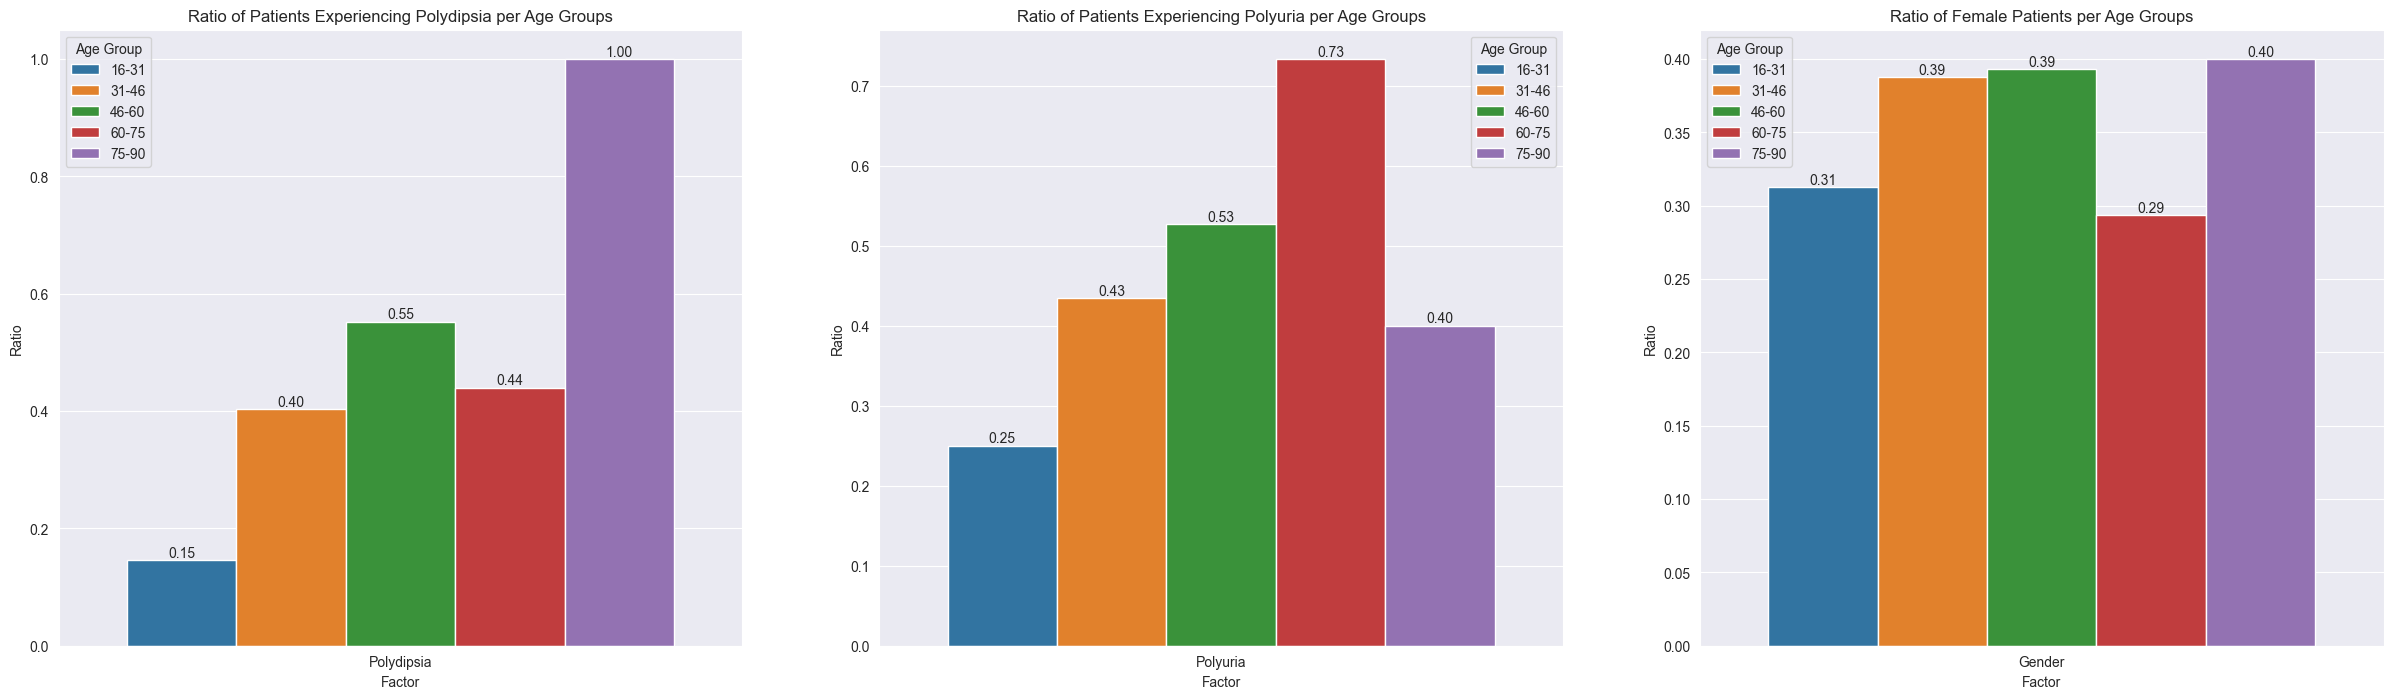

In [8]:
symptoms = ['Polydipsia', 'Polyuria', 'Gender']
diagnosis = ['class']

# cols = np.concat([symptoms, diagnosis, ['Age group']])
cols = np.concat([symptoms, ['Age group']])

symp_df = df[df['class'] == 1]
symp_df = df.loc[:,cols]
symp_df = np.transpose(symp_df.groupby('Age group').mean())

age_groups = symp_df.columns
symp_df.reset_index(inplace=True)

cols = np.concat([['Factor'], age_groups])
symp_df.columns = cols

symp_df = symp_df.melt(
    id_vars='Factor',
    value_vars = age_groups,
    var_name='Age Group',
    value_name='Ratio'
)

palette = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd"   # purple
]

fig, ax = plt.subplots(1,3, figsize=(30,8))

for idx, ax in enumerate(ax.flat):
    factor = symptoms[idx]
    data = symp_df[symp_df['Factor'] == factor]
    sns.barplot(data=data, y='Ratio', x='Factor', hue='Age Group', ax=ax, palette=palette)

    if factor == 'Gender':
        ax.set_title('Ratio of Female Patients per Age Groups')
    else:
        ax.set_title(f'Ratio of Patients Experiencing {factor} per Age Groups')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

plt.savefig("q3.pdf", bbox_inches="tight")
plt.savefig("q3.png", bbox_inches="tight")

There is a clear upward trend in the prevalence of polydipsia with age. The proportion increases from 0.15 in the 16–31 group to 1.00 in the 75–90 group, indicating that nearly all individuals in the oldest age group exhibit this symptom.
This suggests that polydipsia becomes significantly more prominent in older populations, potentially reflecting worsening glucose regulation and dehydration associated with advanced diabetes progression.

A similar pattern is observed for polyuria, with prevalence rising from 0.25 in younger individuals (16–31) to a peak of 0.73 in the 60–75 group, before declining slightly to 0.40 in the 75–90 group. This trend indicates that polyuria is strongly associated with middle-to-older age groups, although the drop in the oldest group may suggest: underreporting; survivorship bias; or physiological differences in symptom expression at advanced ages.

Unlike the other symptoms, the gender-related ratio remains relatively stable across age groups, ranging from 0.29 to 0.40. There is no clear monotonic trend. This suggests that gender is not strongly influenced by age in terms of diabetes prevalence, and its effect is likely more consistent across the population.

## 2.4 Are there distinct groups of patients based on symptoms, and do these groups differ in diabetes outcomes?

In [10]:
df = df_factored.copy()

target = df['class']
features = df.drop('class', axis=1).copy()

To determine the groups of patients, we shall use K-means clustering to determine the clusters of patients. Furthermore, we shall use silhouette score as a metric to determine the optimal number of clusters such that each patient in each cluster has a high similarity with other patients within the same cluster.

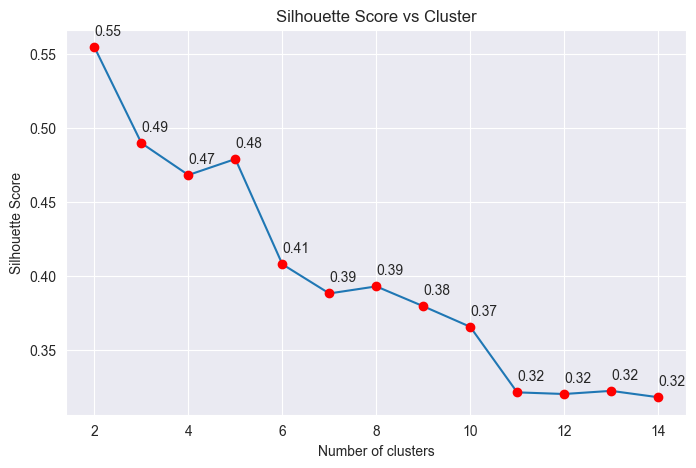

In [11]:
clusters = [i for i in range(2, 15)]
silhouettes = {
    'Cluster' : [],
    'Score': []
}

for cluster in clusters:
    kmeans = KMeans(n_clusters=cluster, random_state=0)
    label = kmeans.fit_predict(df)
    silhouettes['Score'].append(silhouette_score(df, label))
    silhouettes['Cluster'].append(cluster)

silhouettes = pd.DataFrame(silhouettes)

fig, ax = plt.subplots(figsize=(8,5))
sns.lineplot(data=silhouettes, x='Cluster', y='Score', ax=ax)
plt.plot(silhouettes['Cluster'], silhouettes['Score'], 'ro')

for x, y in zip(silhouettes['Cluster'], silhouettes['Score']):
    ax.text(x, y + 0.008, f"{y:.2f}")


plt.title("Silhouette Score vs Cluster")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

After an analysis on the optimal number of cluster on the dataset using K-means clustering technique, we have arrived at an optimal cluster of 2 with a silhouette score of ~0.55. Now, we do an analysis of the features of each cluster.

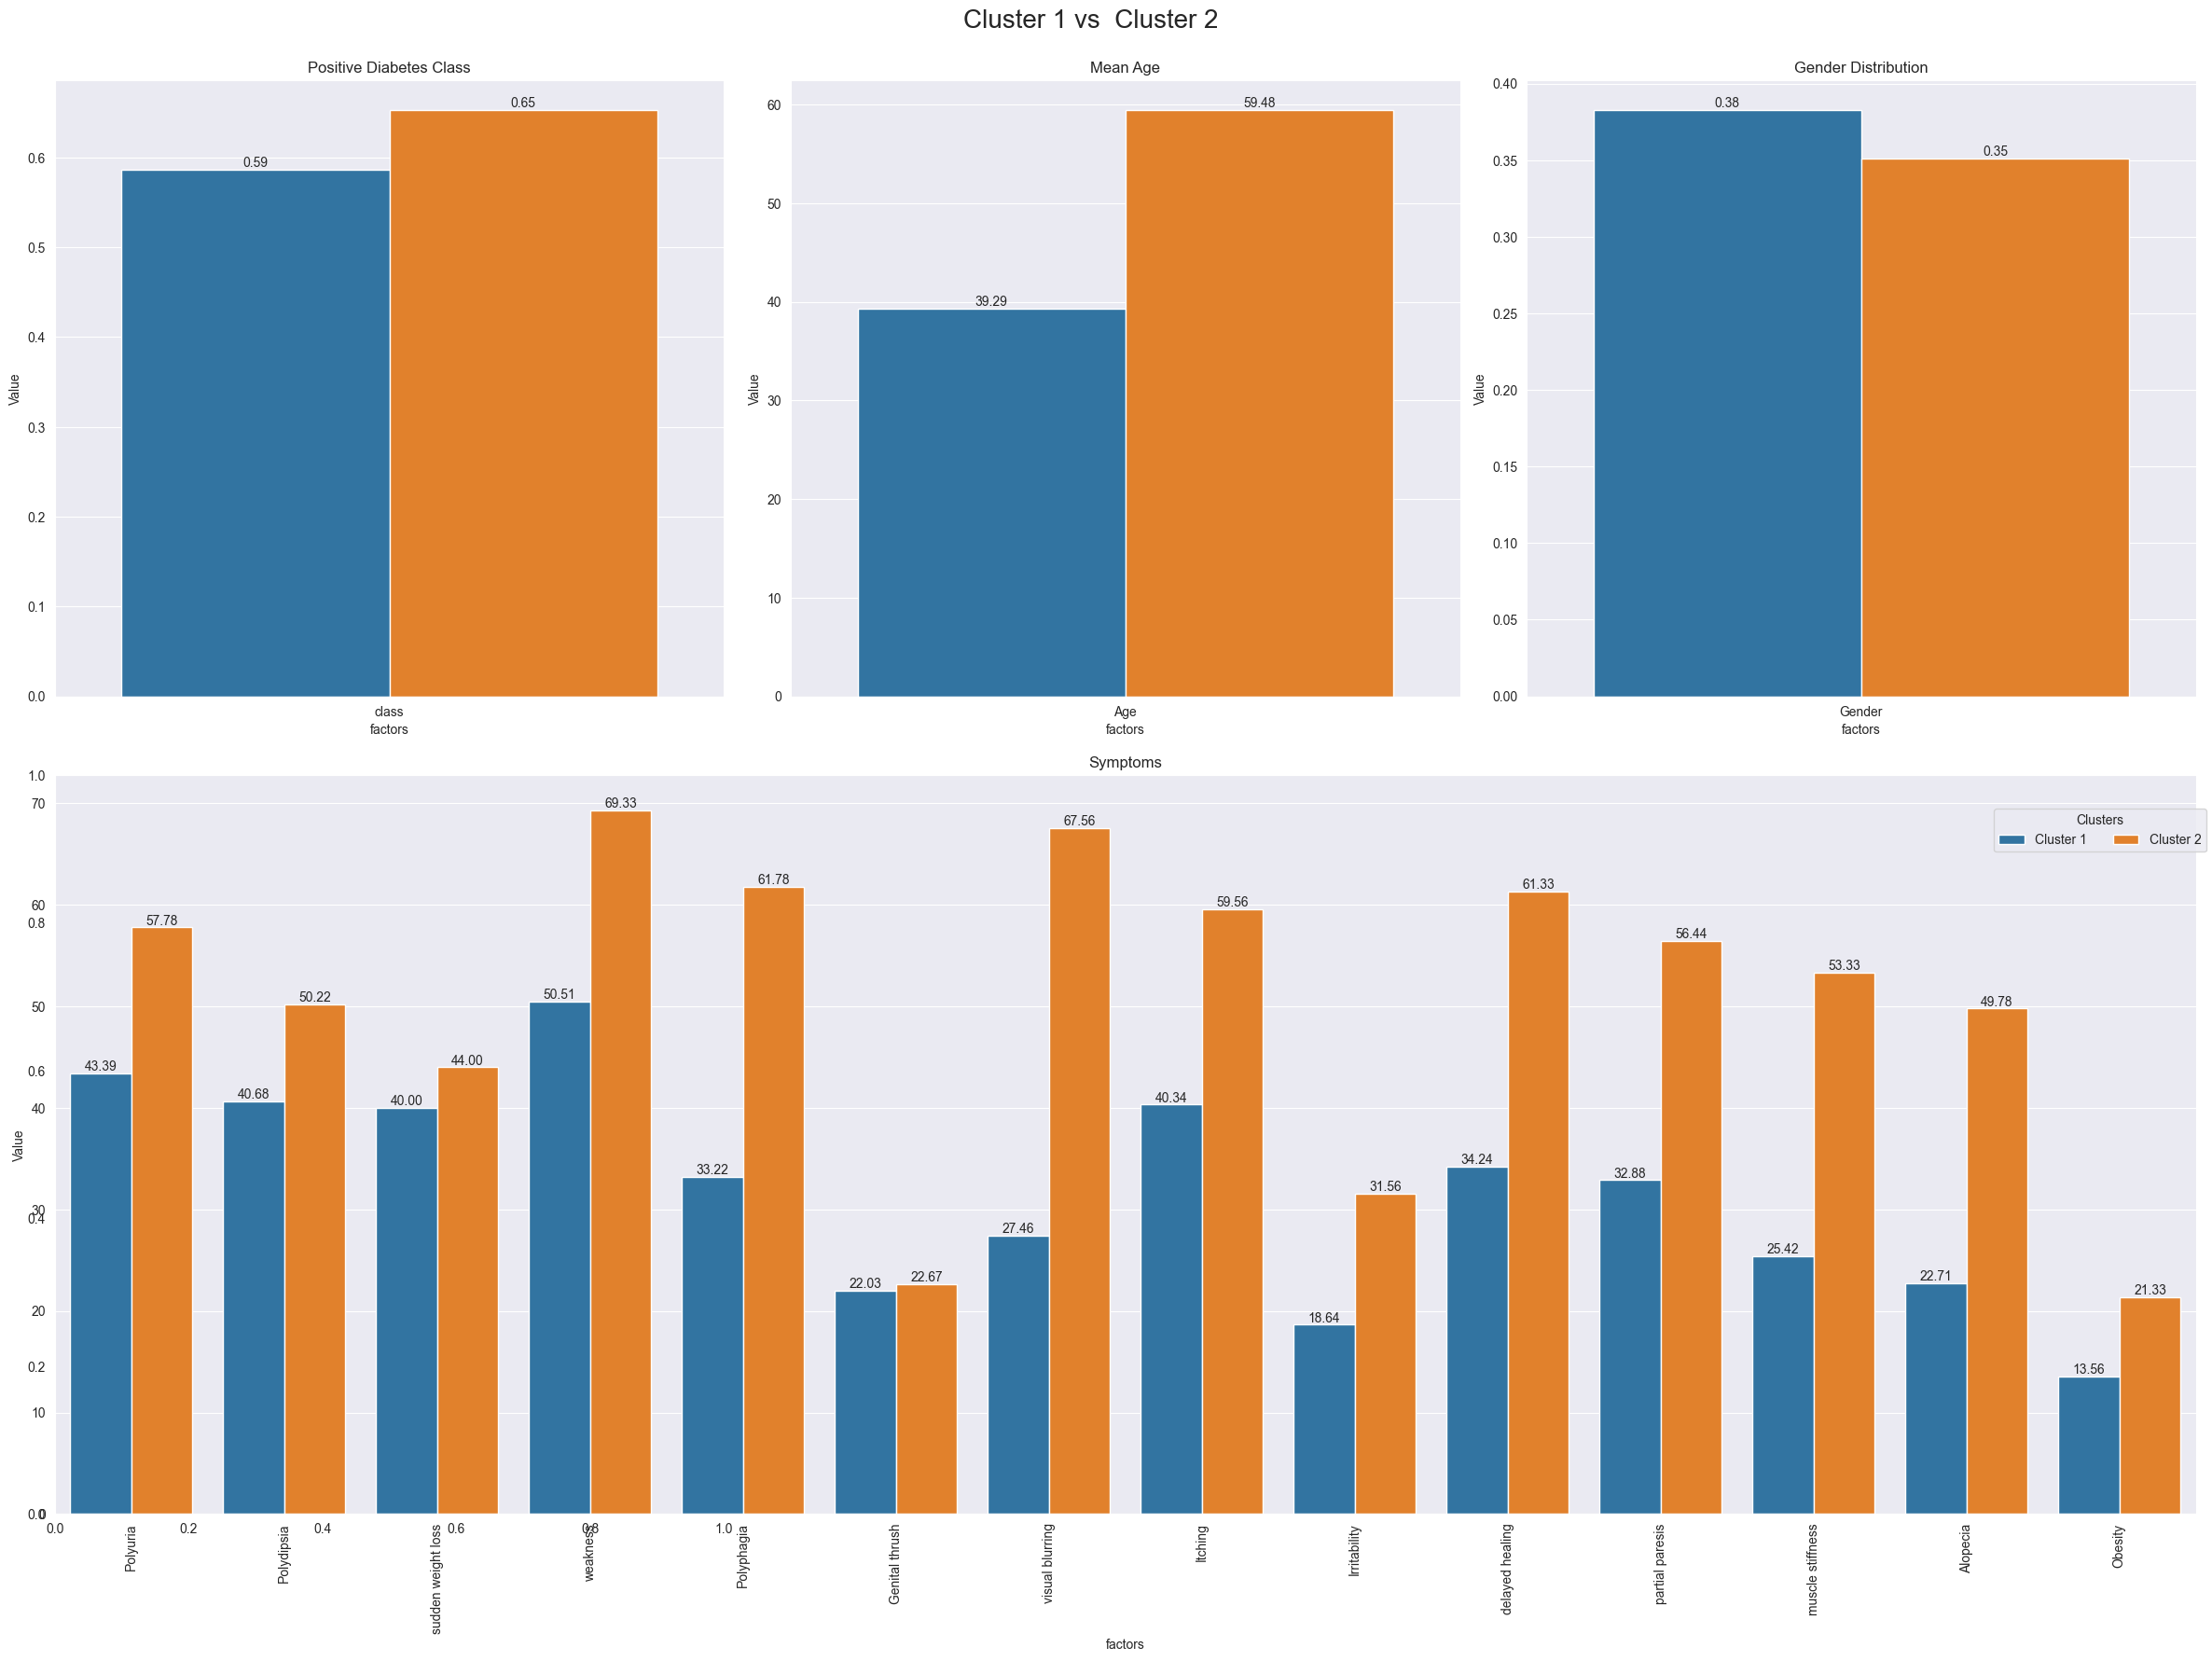

In [13]:
optimal_cluster = silhouettes.loc[silhouettes['Score'].idxmax(), 'Cluster']

kmeans = KMeans(n_clusters=optimal_cluster, random_state=0)
label = kmeans.fit_predict(df)
df_clustered = df.copy()
df_clustered['cluster'] = label
clustered_mean = df_clustered.groupby('cluster').mean().copy()
clustered_mean = np.transpose(clustered_mean).copy()
clustered_mean['factors'] = clustered_mean.index
clustered_mean = clustered_mean.reset_index(drop=True)
clustered_mean.columns = ['Cluster 1', 'Cluster 2', 'factors']

combined = clustered_mean.melt(
    id_vars="factors",
    value_vars=["Cluster 1", "Cluster 2"],
    var_name="Class",
    value_name="Value"
)

categorical_factors = combined.loc[combined['factors'] != 'Age', :].loc[combined['factors'] != 'Gender', :].loc[combined['factors'] != 'class', :]
age = combined.loc[combined['factors'] == 'Age', :]
gender = combined.loc[combined['factors'] == 'Gender', :]
diabetes_class = combined.loc[combined['factors'] == 'class', :]

categorical_factors['Value'] = categorical_factors['Value']*100

fig = plt.figure(figsize=(24, 18))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.2])

ax0 = fig.add_subplot(gs[0, 0])
sns.barplot(data=diabetes_class, x='factors', y='Value', hue='Class', ax=ax0)
ax0.set_title('Positive Diabetes Class')
ax1 = fig.add_subplot(gs[1, 0])

ax1 = fig.add_subplot(gs[0, 1])
sns.barplot(data=age, x='factors', y='Value', hue='Class', ax=ax1)
ax1.set_title('Mean Age')

ax2 = fig.add_subplot(gs[0, 2])
sns.barplot(data=gender, x='factors', y='Value', hue='Class', ax=ax2)
ax2.set_title('Gender Distribution')

ax3 = fig.add_subplot(gs[1, :])
sns.barplot(data=categorical_factors, x='factors', y='Value', hue='Class', ax=ax3)
ax3.set_title('Symptoms')
ax3.tick_params(axis='x', rotation=90)

for ax in [ax0, ax1, ax2, ax3]:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

for ax in [ax0, ax1, ax2, ax3]:
    ax.legend_.remove()

handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, title='Clusters', loc='center right', ncol=2)

fig.suptitle('Cluster 1 vs  Cluster 2', y=1, fontsize=20)
plt.savefig("q4.pdf", bbox_inches="tight")
plt.savefig("q4.png", bbox_inches="tight")

plt.tight_layout()
plt.show()

Since the mean of binary coded variables(0 and 1) is just the percentage of one of the values, we refer to the mean of binary categorical variables as percentage.

According to the graphs above, we can see that Cluster 1 observes a low average generally among all factors except for gender compared to Cluster 2. Cluster 1 has less positive diabetes cases with a percentage of 59% in contrast with the 65% of Cluster 2. Cluster 1 holds a younger set of patients evident by the lower mean age of 39.29 while Cluster 2 has an older set of patients with a mean of 59.48. This is a significant difference of ~20 years. In this dataset, there is a higher distribution of Male patients. This is also true for both clusters. However, Cluster 2 has a higher percentage of women than Cluster 2 with the percentage being 38% and 35% respectively. Lastly, Cluster 2 observes a higher percentage of its patients experiencing these symptoms compared to cluster 1.

 To summarize, Cluster 1 is characterized by a younger set of patients, lower occurrence of diabetes, and also fewer patients experiencing the symptoms. This might be a result of an overall younger set of patients. Since younger patients have a relatively stronger vitality, higher resilience, and a stronger immune system, it may explain the lower presence of symptoms among the patients in the cluster. Additionally, women are more physiologically more resilient than men which may add to the lower symptom presence. In contrast, Cluster 2 is characterized by an older set of patients, higher occurrence of diabetes, and also more patients experiencing the symptoms.

With this, each cluster differ in diabetes outcome. Cluster 1 has 59% of its patients with diabetes and Cluster 2 has 65% of its patents with diabetes. As mentioned above, this difference may be a result of physiological differences like age differences and gender differences.

# Conclusion

This analysis set out to determine whether a small subset of symptoms can effectively explain and predict diabetes outcomes. Across multiple approaches—including logistic regression, LASSO-based feature selection, and age-based analysis—the results consistently point to a high concentration of predictive signal in a few key symptoms.

Particularly, symptoms such as polydipsia and polyuria emerged as strong and consistent indicators of diabetes. Models trained using only the top features performed comparably to the full model, suggesting that additional variables contribute minimal incremental predictive value. This indicates that much of the information relevant to diabetes classification is captured by a limited number of informative factors.

Further analysis showed that the prevalence of these symptoms increases with age, reinforcing their relevance, especially in older populations. At the same time, other factors—such as gender—exhibited relatively stable patterns, suggesting a weaker role in discriminating diabetes outcomes across age groups.

Overall, these findings support the idea that diabetes detection can be simplified without sacrificing performance. By focusing on a small subset of key symptoms, it may be possible to design more efficient and interpretable screening tools, particularly in settings where rapid or resource-constrained decision-making is required.



# Limitations

It is important to note that these results are based on a specific dataset and may not fully generalize to broader or more diverse populations. Additionally, while reduced models perform similarly in this context, more complex interactions between variables may still exist and warrant further investigation.

# References

American Diabetes Association. (n.d.). Diabetes symptoms.
https://diabetes.org/about-diabetes/warning-signs-symptoms

Mayo Clinic. (2026). Diabetes - Symptoms and causes.
https://www.mayoclinic.org/diseases-conditions/diabetes/symptoms-causes/syc-20371444